In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df_pca = pd.read_csv('../data/gaia_pca.csv')

print(df_pca.head())

        PC1       PC2       PC3       PC4
0 -0.596051 -1.400087  0.322000  0.646080
1 -0.773060 -1.361825  0.500167  0.196505
2 -1.744177 -1.482410  0.239986 -0.286465
3  0.922784 -1.124993  0.978373  0.618948
4 -0.828165 -1.341449  0.420942 -0.368206


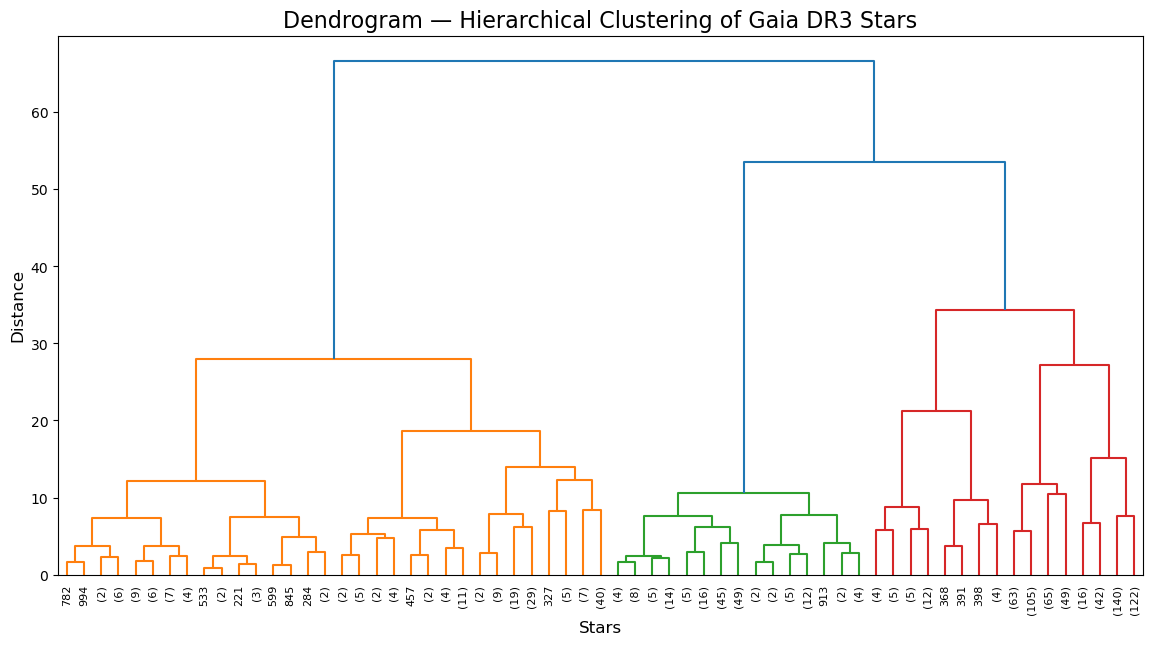

In [2]:
sample = df_pca.sample(1000, random_state=42)

linked = linkage(sample, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked,
           truncate_mode='level',
           p=5,
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=50)
plt.xlabel('Stars', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Dendrogram — Hierarchical Clustering of Gaia DR3 Stars', fontsize=16)
plt.savefig('../images/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
sample_df = df_pca[['PC1','PC2','PC3','PC4']].sample(10000, random_state=42)

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
sample_df = sample_df.copy()
sample_df['hierarchical_cluster'] = hc.fit_predict(sample_df[['PC1','PC2','PC3','PC4']])

print("Cluster counts:")
print(sample_df['hierarchical_cluster'].value_counts())

score = silhouette_score(
    sample_df[['PC1','PC2','PC3','PC4']],
    sample_df['hierarchical_cluster']
)
print(f"\nSilhouette Score: {score:.4f}")

Cluster counts:
hierarchical_cluster
2    6197
1    2331
0    1472
Name: count, dtype: int64

Silhouette Score: 0.4687


In [4]:
sample_df.to_csv('../data/gaia_hierarchical.csv', index=False)
print("Hierarchical results saved!")

Hierarchical results saved!
